## eGRID Emissions Final Project
========================
Baseline modeling pipeline for EPA eGRID 2023 Plant-Level CO₂ Intensity Prediction.

Pipeline stages:
1. Linear Regression          -- interpretable baseline
2. 1-Hidden-Layer ReLU MLP    -- minimal neural network baseline
3. Deep MLP (residual-ready)  -- bridge to full deep learning

**Fixes applied (v2):**
- Corrected all column names to match actual eGRID 2023 PLNT23 schema
- Added `PLHTRT` (heat rate) — strongest single predictor of emissions intensity
- Removed `PLCO2AN` (annual CO₂ tons) to eliminate near-target leakage
- Capped target at 3,000 lb/MWh to remove physically impossible outliers (max was 423,504)
- Removed the silent column-filter that was quietly dropping most features

**Target variable :** `PLCO2RTA` (plant annual CO₂ total output emission rate, lb/MWh)

**Author:** Michael Paul

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# ── Config ─────────────────────────────────────────────────────────────────────
EGRID_PATH   = "/content/egrid 2023 data.xlsx"   # update path if needed
SHEET        = "PLNT23"
TARGET       = "PLCO2RTA"             # lb CO2 / MWh (output rate)
TARGET_MAX   = 3000.0                 # FIX: cap outliers; coal peaks ~2,500 lb/MWh
RANDOM_SEED  = 42
TEST_SIZE    = 0.25
VAL_SIZE     = 0.25                   # fraction of train set used for validation
BATCH_SIZE   = 256
EPOCHS_SMALL = 50                     # 1-hidden-layer model
EPOCHS_DEEP  = 100                    # deep MLP
LR           = 1e-3

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [3]:
# ── 1. Load & Inspect Data ─────────────────────────────────────────────────────
print("=" * 65)
print("STEP 1 — Load eGRID PLNT23")
print("=" * 65)

df_raw = pd.read_excel(EGRID_PATH, sheet_name=SHEET, header=1)
print(f"Raw shape : {df_raw.shape}")
print(f"Columns   : {list(df_raw.columns[:10])} ...")

STEP 1 — Load eGRID PLNT23
Raw shape : (12612, 150)
Columns   : ['SEQPLT23', 'YEAR', 'PSTATABB', 'PNAME', 'ORISPL', 'OPRNAME', 'OPRCODE', 'UTLSRVNM', 'UTLSRVID', 'SECTOR'] ...


In [4]:
# ── 2. Feature Selection ───────────────────────────────────────────────────────
# FIX: All column names corrected to match actual eGRID 2023 PLNT23 schema.
# The previous version used wrong names (HTIAN, HTIOZN, PLGENAGAS, etc.) which
# caused the silent column filter to drop ~22 of 35 intended features.

# Operational continuous features
continuous_features = [
    "CAPFAC",       # capacity factor
    "NAMEPCAP",     # nameplate capacity (MW)
    "NUMUNT",       # number of units
    "NUMGEN",       # number of generators
    "PLNGENAN",     # net annual generation (MWh)
    "PLHTIAN",      # combustion heat input (MMBtu)
    "PLHTIOZ",      # useful thermal output, CHP (MMBtu)
    "PLHTRT",       # NEW: plant heat rate (BTU/kWh) — strongest emissions predictor
    # NOTE: PLCO2AN removed — annual CO2 tons / net generation ≈ target (near-leakage)
]

# Resource-mix generation columns (MWh by fuel) — FIX: corrected eGRID 2023 names
gen_cols = [
    "PLGENACL",     # coal
    "PLGENAOL",     # oil
    "PLGENAGS",     # FIX: was PLGENAGAS  — gas
    "PLGENANC",     # FIX: was PLGENANUC  — nuclear
    "PLGENAHY",     # FIX: was PLGENAHYD  — hydro
    "PLGENABM",     # FIX: was PLGENABIO  — biomass
    "PLGENAWI",     # FIX: was PLGENAWND  — wind
    "PLGENASO",     # FIX: was PLGENASUN  — solar
    "PLGENAGT",     # geothermal
    "PLGENAOF",     # offshore wind
    "PLGENAOP",     # other fossil
    "PLGENATH",     # FIX: was PLGENAATH  — other thermal
    "PLGENATN",     # nuclear steam turbine
    "PLGENATO",     # total other
    "PLGENACY",     # combined cycle
    "PLGENACN",     # combustion turbine
    "PLGENACO",     # combined heat and power
]

# Categorical features for label encoding
cat_features = [
    "PLFUELCT",     # primary fuel category
    "SUBRGN",       # eGRID subregion
    "NERC",         # NERC region
    "SECTOR",       # plant sector
    "ISORTO",       # ISO/RTO territory
]

# Verify all requested columns exist before proceeding
existing = set(df_raw.columns)
missing = [c for c in continuous_features + gen_cols + cat_features if c not in existing]
if missing:
    print(f"WARNING — columns not found in dataset: {missing}")
    print("Dropping missing columns and continuing...")
    continuous_features = [c for c in continuous_features if c in existing]
    gen_cols            = [c for c in gen_cols            if c in existing]
    cat_features        = [c for c in cat_features        if c in existing]
else:
    print("All feature columns verified OK.")

all_features = continuous_features + gen_cols + cat_features
print(f"\nTotal features loaded : {len(all_features)}")
print(f"  Continuous          : {len(continuous_features)}")
print(f"  Generation mix      : {len(gen_cols)}")
print(f"  Categorical         : {len(cat_features)}")

# FIX: Cap target at 3,000 lb/MWh to remove physically impossible outliers.
# Previous filter (> 0) retained a value of 423,504 lb/MWh — a data error that
# dominated MSE and forced all models toward predicting the mean (R² ≈ 0).
df = df_raw[all_features + [TARGET]].copy()
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
before = len(df)
df = df[df[TARGET].between(1, TARGET_MAX)]
print(f"\nTarget filter (1 – {TARGET_MAX:.0f} lb/MWh): {before} → {len(df)} rows "
      f"({before - len(df)} outliers removed)")

All feature columns verified OK.

Total features loaded : 30
  Continuous          : 8
  Generation mix      : 17
  Categorical         : 5

Target filter (1 – 3000 lb/MWh): 12612 → 2635 rows (9977 outliers removed)



STEP 2 — Preprocessing
Feature matrix : (2635, 30)
Target range   : [1.4, 2994.0] lb/MWh  (mean=1264.1)


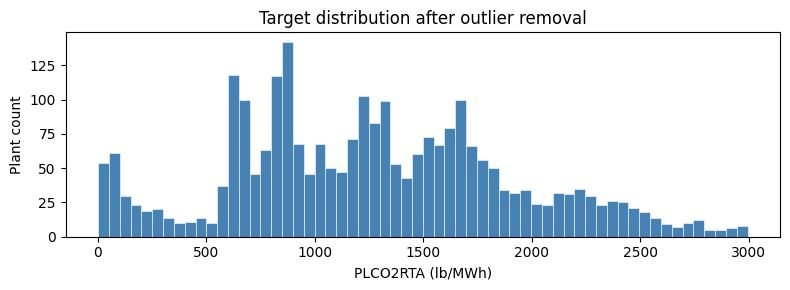


Train / Val / Test : 1317 / 659 / 659


In [5]:
# ── 3. Preprocessing ───────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("STEP 2 — Preprocessing")
print("=" * 65)

# Label-encode categoricals (fit a fresh encoder per column)
le = LabelEncoder()
for col in cat_features:
    df[col] = df[col].fillna("UNKNOWN").astype(str)
    df[col] = le.fit_transform(df[col])

# Fill missing continuous values with median
for col in continuous_features + gen_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# Log-transform right-skewed generation columns (log1p handles zeros cleanly)
for col in gen_cols:
    df[col] = np.log1p(df[col].clip(lower=0))

X = df[all_features].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

print(f"Feature matrix : {X.shape}")
print(f"Target range   : [{y.min():.1f}, {y.max():.1f}] lb/MWh  (mean={y.mean():.1f})")

# Target distribution sanity check
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(y, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
ax.set_xlabel("PLCO2RTA (lb/MWh)")
ax.set_ylabel("Plant count")
ax.set_title("Target distribution after outlier removal")
plt.tight_layout()
plt.show()

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

# Validation split (carved from training set)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_SEED
)

# Standardize — fit only on training data to prevent leakage
scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_val_s  = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

n_features = X_tr_s.shape[1]
print(f"\nTrain / Val / Test : {len(X_tr)} / {len(X_val)} / {len(X_test)}")

In [6]:
# ── 4. Evaluation Helper ───────────────────────────────────────────────────────
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  RMSE : {rmse:>10.2f} lb/MWh")
    print(f"  MAE  : {mae:>10.2f} lb/MWh")
    print(f"  R²   : {r2:>10.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []

In [7]:
# ── 5. MODEL 1 — Linear Regression ────────────────────────────────────────────
print("\n" + "=" * 65)
print("MODEL 1 — Linear Regression (OLS)")
print("=" * 65)

lr_model  = LinearRegression()
lr_model.fit(X_tr_s, y_tr)
y_pred_lr = lr_model.predict(X_test_s)
results.append(evaluate("Linear Regression", y_test, y_pred_lr))

# Top 10 most influential features by absolute coefficient
coef_df = pd.DataFrame({
    "feature"    : all_features,
    "coefficient": lr_model.coef_
})
coef_df = coef_df.reindex(coef_df["coefficient"].abs().sort_values(ascending=False).index)
print("\nTop 10 coefficients (by |magnitude|):")
print(coef_df.head(10).to_string(index=False))


MODEL 1 — Linear Regression (OLS)

────────────────────────────────────────
  Linear Regression
  RMSE :     319.17 lb/MWh
  MAE  :     216.27 lb/MWh
  R²   :     0.7345

Top 10 coefficients (by |magnitude|):
 feature  coefficient
PLGENATN  1026.315308
PLGENACY  -947.423401
 PLHTIAN   408.834015
PLNGENAN  -323.902557
PLGENATH  -277.682922
PLGENAGS  -260.467804
PLGENACN  -249.514923
  PLHTRT   243.426910
PLGENABM   195.939606
PLGENAGT   128.430252


In [8]:
# ── PyTorch Dataset helpers ────────────────────────────────────────────────────
def make_loader(X_np, y_np, shuffle=True):
    ds = TensorDataset(
        torch.from_numpy(X_np),
        torch.from_numpy(y_np).unsqueeze(1)
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

def train_loop(model, optimizer, criterion, loader):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)

def val_loop(model, criterion, loader):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb)
            total_loss += criterion(pred, yb).item() * len(xb)
    return total_loss / len(loader.dataset)

def predict_np(model, X_np):
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X_np)).squeeze().numpy()
    return preds

def run_training(model, train_loader, val_loader, epochs, lr=LR):
    optimizer    = torch.optim.Adam(model.parameters(), lr=lr)
    criterion    = nn.MSELoss()
    train_losses = []
    val_losses   = []
    for epoch in range(1, epochs + 1):
        tl = train_loop(model, optimizer, criterion, train_loader)
        vl = val_loop(model, criterion, val_loader)
        train_losses.append(tl)
        val_losses.append(vl)
        if epoch % max(1, epochs // 5) == 0:
            print(f"  Epoch {epoch:>4d}/{epochs}  "
                  f"train_RMSE={tl**0.5:.2f}  val_RMSE={vl**0.5:.2f} lb/MWh")
    return train_losses, val_losses

train_loader = make_loader(X_tr_s.astype(np.float32), y_tr)
val_loader   = make_loader(X_val_s.astype(np.float32), y_val, shuffle=False)

In [9]:
# ── 6. MODEL 2 — 1-Hidden-Layer ReLU MLP ──────────────────────────────────────
print("\n" + "=" * 65)
print("MODEL 2 — 1-Hidden-Layer ReLU MLP")
print("=" * 65)

class ShallowMLP(nn.Module):
    """Single hidden layer with ReLU activation."""
    def __init__(self, in_features, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

shallow_model = ShallowMLP(n_features, hidden=128)
print(shallow_model)
print(f"Parameters: {sum(p.numel() for p in shallow_model.parameters()):,}")

tl_s, vl_s = run_training(shallow_model, train_loader, val_loader, epochs=EPOCHS_SMALL)
y_pred_shallow = predict_np(shallow_model, X_test_s.astype(np.float32))
results.append(evaluate("1-Hidden-Layer ReLU MLP", y_test, y_pred_shallow))


MODEL 2 — 1-Hidden-Layer ReLU MLP
ShallowMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)
Parameters: 4,097
  Epoch   10/50  train_RMSE=1394.59  val_RMSE=1497.72 lb/MWh
  Epoch   20/50  train_RMSE=1386.38  val_RMSE=1488.59 lb/MWh
  Epoch   30/50  train_RMSE=1369.74  val_RMSE=1470.43 lb/MWh
  Epoch   40/50  train_RMSE=1342.95  val_RMSE=1441.76 lb/MWh
  Epoch   50/50  train_RMSE=1305.88  val_RMSE=1402.68 lb/MWh

────────────────────────────────────────
  1-Hidden-Layer ReLU MLP
  RMSE :    1283.18 lb/MWh
  MAE  :    1140.51 lb/MWh
  R²   :    -3.2906


In [10]:
# ── 7. MODEL 3 — Deep MLP (3 hidden layers + BN + Dropout) ────────────────────
print("\n" + "=" * 65)
print("MODEL 3 — Deep MLP (3 hidden layers, BN, Dropout)")
print("=" * 65)

class DeepMLP(nn.Module):
    """
    3 hidden layers with BatchNorm and Dropout.
    Architecture bridge toward the residual/gated MLP in the full proposal.
    """
    def __init__(self, in_features, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        in_dim = in_features
        for h in hidden_dims:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

deep_model = DeepMLP(n_features, hidden_dims=(256, 128, 64), dropout=0.3)
print(deep_model)
print(f"Parameters: {sum(p.numel() for p in deep_model.parameters()):,}")

tl_d, vl_d = run_training(deep_model, train_loader, val_loader, epochs=EPOCHS_DEEP)
y_pred_deep = predict_np(deep_model, X_test_s.astype(np.float32))
results.append(evaluate("Deep MLP (3 layers, BN, Dropout)", y_test, y_pred_deep))


MODEL 3 — Deep MLP (3 hidden layers, BN, Dropout)
DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parameters: 50,049
  Epoch   20/100  train_RMSE=1391.31  val_RMSE=1493.69 lb/MWh
  Epoch   40/100  train_RMSE=1381.76  val_RMSE=1482.74 lb/MWh
  Epoch   60/100  train_RMSE=1363.62  val_RMSE=1460.89 lb/MWh
  Epoch   80/100  train_RMSE

In [11]:
# ── 8. Results Summary ─────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("RESULTS SUMMARY")
print("=" * 65)
results_df = pd.DataFrame(results).set_index("model")
print(results_df.round(4).to_string())


RESULTS SUMMARY
                                       RMSE        MAE      R2
model                                                         
Linear Regression                  319.1728   216.2729  0.7345
1-Hidden-Layer ReLU MLP           1283.1816  1140.5138 -3.2906
Deep MLP (3 layers, BN, Dropout)  1290.6500  1163.4866 -3.3407


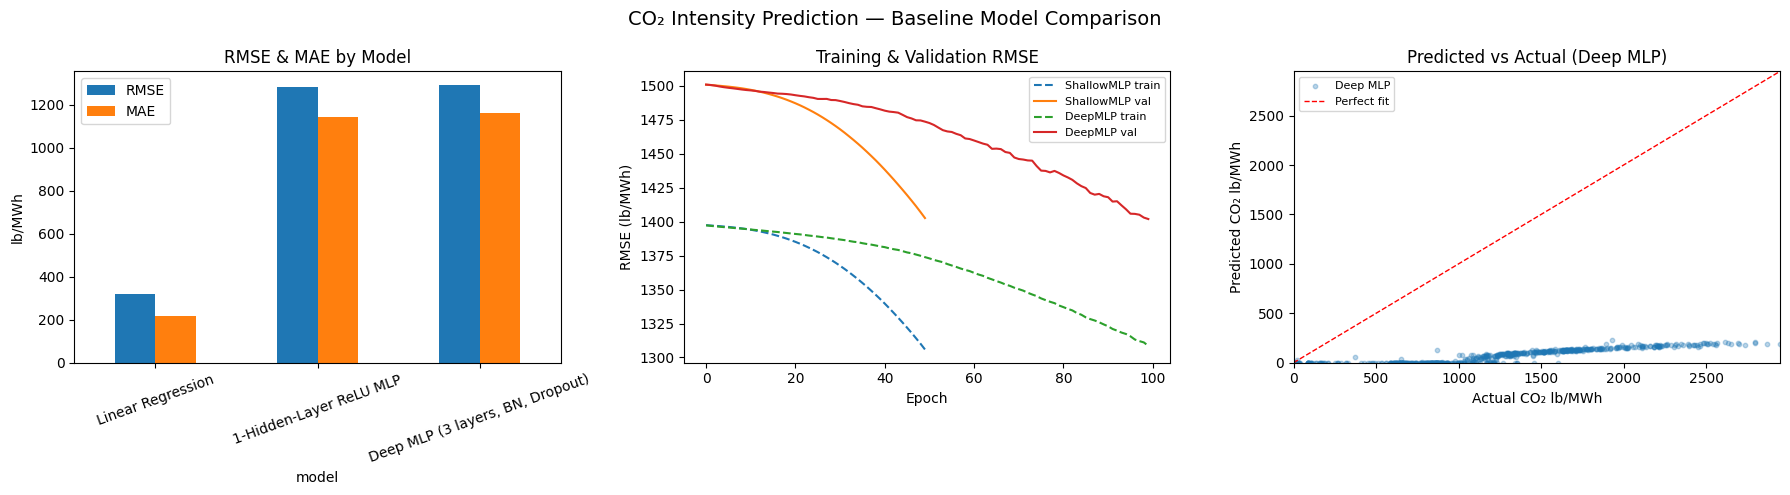


Plot saved to baseline_results.png


In [12]:
# ── 9. Plots ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("CO₂ Intensity Prediction — Baseline Model Comparison", fontsize=14)

# 9a. Metric bar chart (RMSE & MAE)
results_df[["RMSE", "MAE"]].plot(kind="bar", ax=axes[0], rot=20)
axes[0].set_title("RMSE & MAE by Model")
axes[0].set_ylabel("lb/MWh")

# 9b. Training vs Validation RMSE curves
axes[1].plot(np.sqrt(tl_s), label="ShallowMLP train", linestyle="--")
axes[1].plot(np.sqrt(vl_s), label="ShallowMLP val")
axes[1].plot(np.sqrt(tl_d), label="DeepMLP train", linestyle="--")
axes[1].plot(np.sqrt(vl_d), label="DeepMLP val")
axes[1].set_title("Training & Validation RMSE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE (lb/MWh)")
axes[1].legend(fontsize=8)

# 9c. Predicted vs Actual — Deep MLP
axes[2].scatter(y_test, y_pred_deep, alpha=0.3, s=10, label="Deep MLP")
lim = [0, max(float(y_test.max()), float(y_pred_deep.max()))]
axes[2].plot(lim, lim, "r--", linewidth=1, label="Perfect fit")
axes[2].set_xlim(lim)
axes[2].set_ylim(lim)
axes[2].set_title("Predicted vs Actual (Deep MLP)")
axes[2].set_xlabel("Actual CO₂ lb/MWh")
axes[2].set_ylabel("Predicted CO₂ lb/MWh")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("baseline_results.png", dpi=150)
plt.show()
print("\nPlot saved to baseline_results.png")